In [1]:
#@title Multi-source embedding visualization — 2 datasets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

try:
    import umap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'umap-learn', '-q'])
    import umap

RANDOM_SEED = 42

# ═══════════════════════════════════════════════════════════════════════════════
# 1. Load embeddings from each dataset
# ═══════════════════════════════════════════════════════════════════════════════
datasets = {
    'Adriatic Sea': '/data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA',
    'DOLPHINFREE': '/data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE',
}

all_X = []
all_labels = []
all_sources = []

for name, base_path in datasets.items():
    X = np.load(f'{base_path}/embeddings/X_embeddings.npy')
    y = np.load(f'{base_path}/embeddings/y_labels.npy')

    all_X.append(X)
    all_labels.append(y)
    all_sources.append(np.array([name] * len(X)))

    print(f'{name}: {X.shape[0]} windows, {X.shape[1]}d embeddings')
    unique, counts = np.unique(y, return_counts=True)
    for u, c in zip(unique, counts):
        print(f'  {u:25s} n={c}')

X_all = np.concatenate(all_X)
y_all = np.concatenate(all_labels)
sources_all = np.concatenate(all_sources)

print(f'\nCombined: {X_all.shape[0]} windows, {X_all.shape[1]}d')

# ═══════════════════════════════════════════════════════════════════════════════
# 2. Standardize + PCA
# ═══════════════════════════════════════════════════════════════════════════════
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

pca_full = PCA(random_state=RANDOM_SEED)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

n90 = np.argmax(cumvar >= 90) + 1
print(f'PCA: {n90} components for 90% variance')

pca_red = PCA(n_components=n90, random_state=RANDOM_SEED)
X_pca = pca_red.fit_transform(X_scaled)

pca2 = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca2 = pca2.fit_transform(X_scaled)

# ═══════════════════════════════════════════════════════════════════════════════
# 3. t-SNE + UMAP on PCA-reduced data
# ═══════════════════════════════════════════════════════════════════════════════
metric = 'cosine'

print(f'Running t-SNE ({metric})...')
tsne = TSNE(n_components=2, perplexity=40, learning_rate='auto',
            init='random', max_iter=1000, metric=metric,
            random_state=RANDOM_SEED, verbose=0)
X_tsne = tsne.fit_transform(X_pca)

print(f'Running UMAP ({metric})...')
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2,
                     metric=metric, random_state=RANDOM_SEED, verbose=False)
X_umap = reducer.fit_transform(X_pca)

alpha = 0.4
s = 8

2026-04-30 14:30:05.656658: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-30 14:30:05.710861: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-30 14:30:06.959586: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Adriatic Sea: 1180 windows, 1536d embeddings
  background                n=238
  click+whistle             n=194
  click_only                n=702
  whistle_only              n=46
DOLPHINFREE: 3290 windows, 1536d embeddings
  background                n=2140
  whistle                   n=1150

Combined: 4470 windows, 1536d
PCA: 237 components for 90% variance
Running t-SNE (cosine)...
Running UMAP (cosine)...


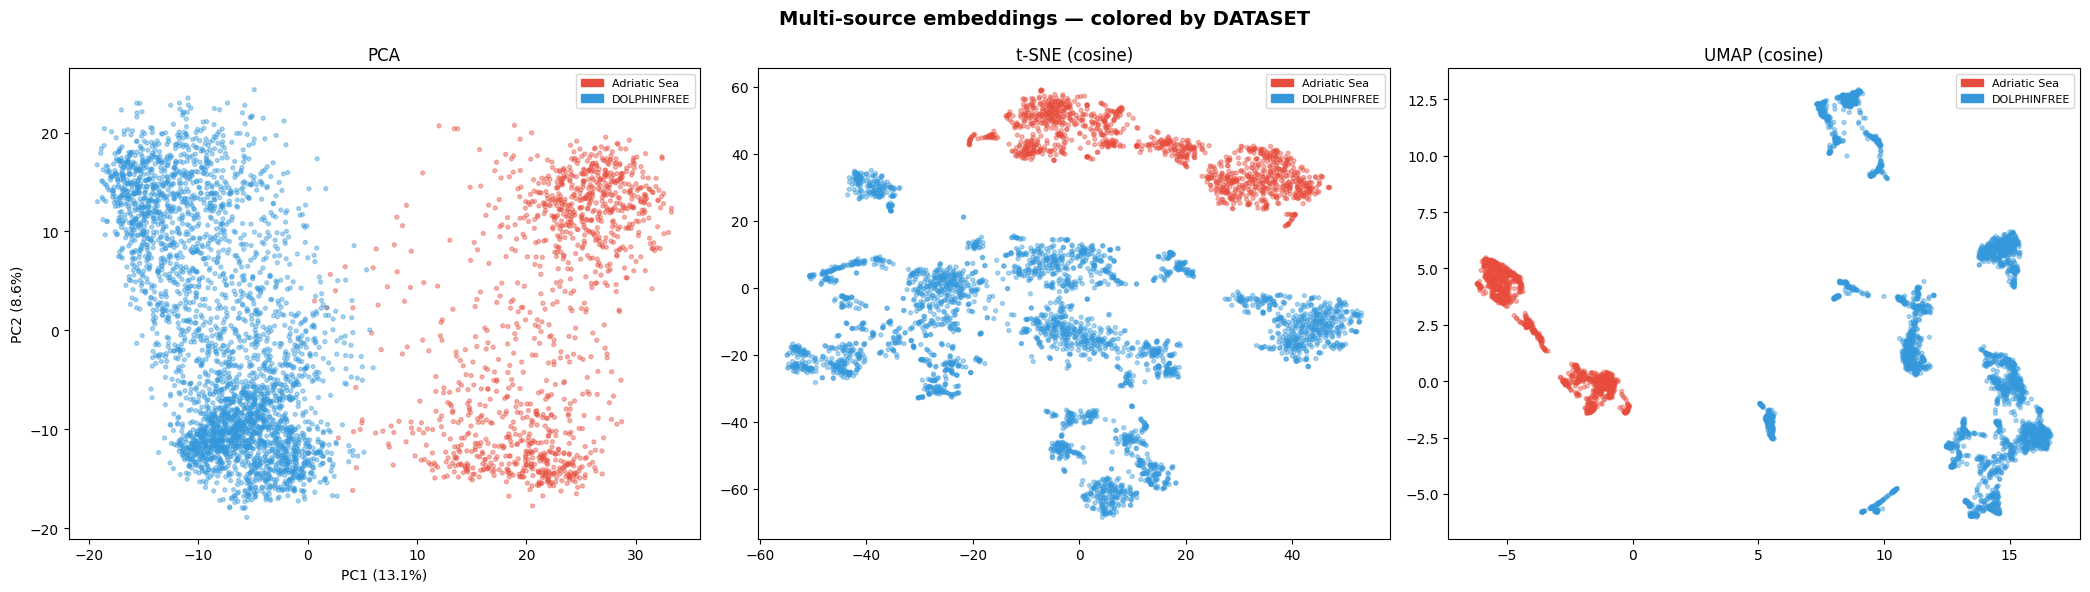

In [2]:
#@title Plot 1: Colored by DATASET SOURCE
source_colors = {
    'Adriatic Sea': '#e74c3c',
    'DOLPHINFREE': '#3498db',
}
c_source = np.array([source_colors[s] for s in sources_all])
patches_source = [mpatches.Patch(color=v, label=k) for k, v in source_colors.items()]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=c_source, alpha=alpha, s=s)
axes[0].set_title('PCA')
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(handles=patches_source, fontsize=8)

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=c_source, alpha=alpha, s=s)
axes[1].set_title(f't-SNE ({metric})')
axes[1].legend(handles=patches_source, fontsize=8)

axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=c_source, alpha=alpha, s=s)
axes[2].set_title(f'UMAP ({metric})')
axes[2].legend(handles=patches_source, fontsize=8)

plt.suptitle('Multi-source embeddings — colored by DATASET', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

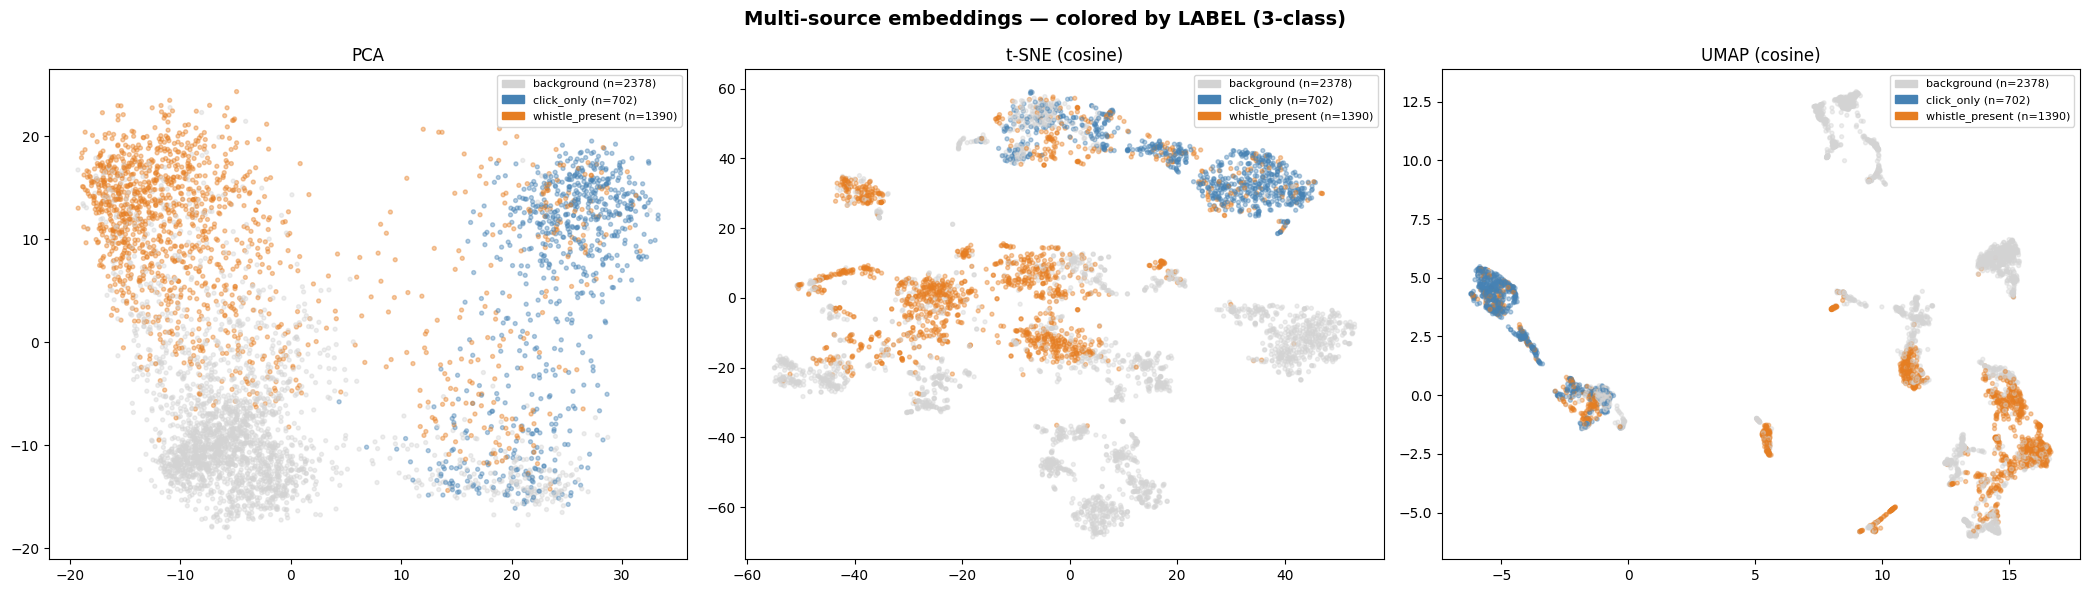

In [3]:
#@title Plot 2: Colored by LABEL (3-class merged)
label_remap = {
    'background': 'background',
    'click_only': 'click_only',
    'click': 'click_only',
    'whistle_only': 'whistle_present',
    'whistle_present': 'whistle_present',
    'click+whistle': 'whistle_present',
    'whistle': 'whistle_present',
    'echolocation': 'click_only',
    'burst_pulse': 'click_only',
    'feeding_buzz': 'click_only',
}
y_merged = np.array([label_remap.get(l, 'other') for l in y_all])

label_colors = {
    'background': '#d3d3d3',
    'click_only': '#4682b4',
    'whistle_present': '#e67e22',
    'other': '#999999',
}
c_label = np.array([label_colors.get(l, '#999999') for l in y_merged])
patches_label = [mpatches.Patch(color=v, label=f'{k} (n={np.sum(y_merged==k)})')
                 for k, v in label_colors.items() if k in y_merged]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=c_label, alpha=alpha, s=s)
axes[0].set_title('PCA')
axes[0].legend(handles=patches_label, fontsize=8)

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=c_label, alpha=alpha, s=s)
axes[1].set_title(f't-SNE ({metric})')
axes[1].legend(handles=patches_label, fontsize=8)

axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=c_label, alpha=alpha, s=s)
axes[2].set_title(f'UMAP ({metric})')
axes[2].legend(handles=patches_label, fontsize=8)

plt.suptitle('Multi-source embeddings — colored by LABEL (3-class)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()